
---

### **Unsupervised Learning and Clustering Techniques – Q\&A**

---

**1. What is unsupervised learning in the context of machine learning?**
Unsupervised learning refers to a type of machine learning where the algorithm is given unlabeled data and tries to find patterns, structure, or groupings on its own. Clustering and dimensionality reduction are common unsupervised learning tasks.

---

**2. How does the K-Means clustering algorithm work?**
K-Means partitions the dataset into `k` clusters by initializing centroids, assigning each point to the nearest centroid, then recalculating centroids as the mean of assigned points. This process repeats until convergence (centroids don't change).

---

**3. Explain the concept of a dendrogram in hierarchical clustering.**
A dendrogram is a tree-like diagram that records the sequences of merges or splits in hierarchical clustering. It visually represents how clusters are formed step by step based on similarity.

---

**4. What is the main difference between K-Means and Hierarchical Clustering?**
K-Means requires specifying the number of clusters `k` in advance and forms flat clusters, while Hierarchical Clustering creates a hierarchy (tree) and does not require a predefined number of clusters.

---

**5. What are the advantages of DBSCAN over K-Means?**

* Does not require the number of clusters `k` in advance
* Can find clusters of arbitrary shapes
* Can identify noise/outliers
* Better suited for datasets with varying densities

---

**6. When would you use Silhouette Score in clustering?**
Silhouette Score is used to evaluate the quality of clustering by measuring both intra-cluster cohesion and inter-cluster separation. It helps in selecting the optimal number of clusters `k`.

---

**7. What are the limitations of Hierarchical Clustering?**

* Computationally expensive (not scalable to large datasets)
* Sensitive to noise and outliers
* Once a merge or split is done, it cannot be undone (no flexibility)

---

**8. Why is feature scaling important in clustering algorithms like K-Means?**
K-Means uses Euclidean distance, which is sensitive to feature magnitude. Without scaling, features with larger ranges dominate the clustering process, leading to biased results.

---

**9. How does DBSCAN identify noise points?**
Points that are not core points and do not fall within the ε-neighborhood of any core point are labeled as **noise** or **outliers** in DBSCAN.

---

**10. Define inertia in the context of K-Means.**
Inertia is the sum of squared distances between each point and its assigned cluster centroid. It measures cluster compactness; lower inertia indicates tighter clusters.

---

**11. What is the elbow method in K-Means clustering?**
The elbow method involves plotting inertia vs. number of clusters `k` and selecting the `k` at the "elbow point" where inertia stops decreasing sharply — indicating optimal cluster count.

---

**12. Describe the concept of "density" in DBSCAN.**
In DBSCAN, density refers to the number of data points within a specified distance (ε). High-density areas form clusters, and areas with insufficient points are treated as noise.

---

**13. Can hierarchical clustering be used on categorical data?**
Yes, but standard distance metrics like Euclidean don't work well. For categorical data, specialized distance measures (e.g., Hamming, Jaccard) or encodings must be used.

---

**14. What does a negative Silhouette Score indicate?**
A negative score means the data point is likely misclassified — it's closer to another cluster than its own. This indicates poor clustering or an outlier.

---

**15. Explain the term "linkage criteria" in hierarchical clustering.**
Linkage criteria determine how the distance between clusters is calculated. Common methods include:

* Single linkage: shortest distance
* Complete linkage: longest distance
* Average linkage: mean distance
* Ward's method: minimizes variance

---

**16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?**
K-Means assumes clusters are spherical and of equal size/density. It struggles with irregular shapes, varying densities, or when clusters are not well-separated.

---

**17. What are the core parameters in DBSCAN, and how do they influence clustering?**

* `eps` (ε): radius for neighborhood
* `min_samples`: minimum points to form a dense region
  Larger `eps` merges nearby clusters, and higher `min_samples` makes clusters harder to form.

---

**18. How does K-Means++ improve upon standard K-Means initialization?**
K-Means++ chooses initial centroids more strategically, spreading them out in dense regions. This reduces the chances of poor initialization and often leads to better convergence.

---

**19. What is agglomerative clustering?**
Agglomerative clustering is a bottom-up hierarchical method where each data point starts as its own cluster. Pairs of clusters are merged step-by-step based on distance criteria until all are joined.

---

**20. What makes Silhouette Score a better metric than just inertia for model evaluation?**
Inertia only measures compactness and always decreases as `k` increases. Silhouette Score balances both **cohesion** (intra-cluster) and **separation** (inter-cluster), making it more robust for evaluating clustering quality.

---


In [1]:
from sklearn.datasets import make_blobs,make_moons,load_iris,load_breast_cancer,load_wine
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


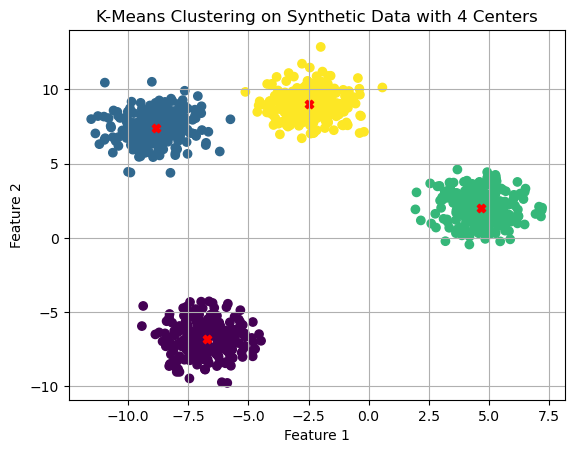

In [2]:
#21 Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot
X,y= make_blobs(n_samples=1000,n_features=2,centers=4,random_state=42)
model=KMeans(n_clusters=4)
y_labels =model.fit_predict(X)

plt.scatter(X[:,0],X[:,1],c=y_labels)
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],c="red", label='Centroids', marker='X')
plt.title("K-Means Clustering on Synthetic Data with 4 Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


In [3]:
#22  Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels
X,y=load_iris(return_X_y=True)
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)
agglom = AgglomerativeClustering(n_clusters=3)
agglom.fit_predict(X_scale)
print("First 10 predicted cluster labels:", agglom.labels_[:10])


First 10 predicted cluster labels: [1 1 1 1 1 1 1 1 1 1]


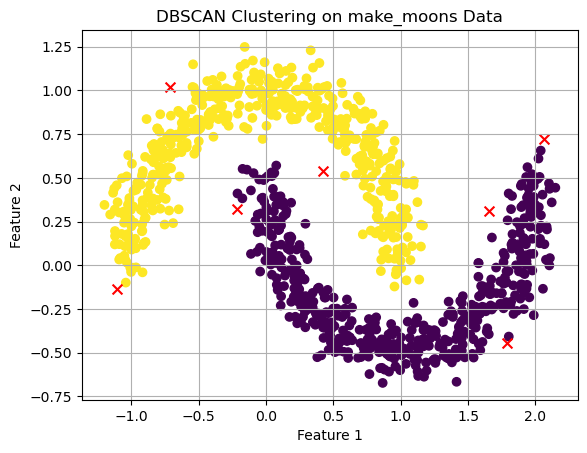

In [4]:
#23 Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot
X,y =make_moons(n_samples=1000,noise=0.1)
dbscan = DBSCAN(eps=.14,min_samples=10)
y_labels=dbscan.fit_predict(X)
y_outlier = y_labels==-1
core_points=y_labels!=-1

plt.scatter(X[core_points,0],X[core_points,1],c=y_labels[core_points])
plt.scatter(X[y_outlier,0],X[y_outlier,1],label='Outliers',c="red", marker='x',s=50)

plt.title("DBSCAN Clustering on make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


In [5]:
# 24.Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster
X,y= load_wine(return_X_y=True)
scaler = StandardScaler()
X_scale=scaler.fit_transform(X)
model=KMeans(n_clusters=3)
y_labels =model.fit_predict(X_scale)

unique, counts = np.unique(y_labels, return_counts=True)
print("Cluster sizes:")
for cluster, size in zip(unique, counts):
    print(f"Cluster {cluster}: {size} samples")

Cluster sizes:
Cluster 0: 63 samples
Cluster 1: 64 samples
Cluster 2: 51 samples


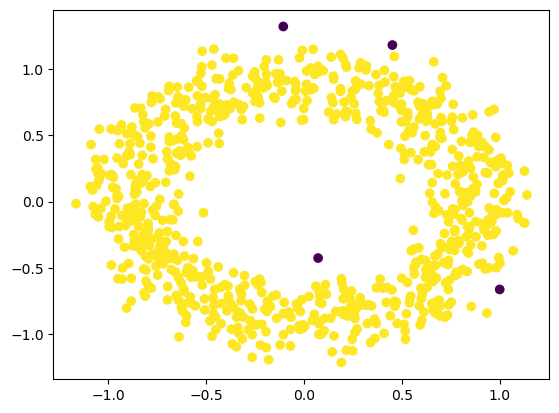

In [6]:
# 25 Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result
from sklearn.datasets import make_circles
X,y=make_circles(noise=0.1,n_samples=800)
y_labels =DBSCAN(eps=0.15).fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=y_labels)

In [7]:
# 26 Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
X,y =load_breast_cancer(return_X_y=True)
scaler = MinMaxScaler()
X_scale=scaler.fit_transform(X)

kmean =KMeans(n_clusters=2)
labels=kmean.fit_predict(X_scale)

print("Cluster Centroids (scaled space):\n", kmean.cluster_centers_)

Cluster Centroids (scaled space):
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


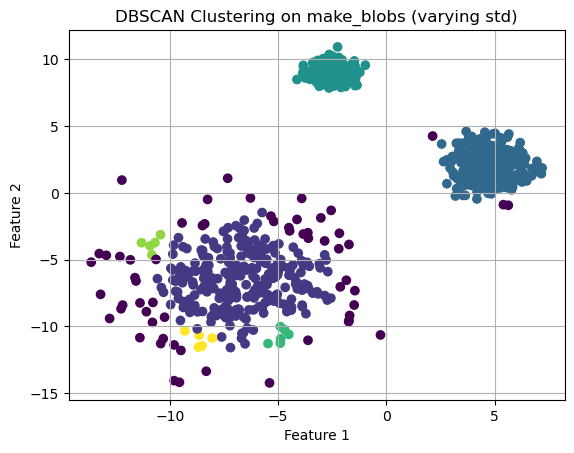

In [8]:
# 27 Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN
X,y =make_blobs(n_features=2,n_samples=1000,centers=3,cluster_std=[0.5, 1.0, 2.5],random_state=42)
scaler = StandardScaler()
X_scale=scaler.fit_transform(X)

kmean =DBSCAN(eps=.15)
labels=kmean.fit_predict(X_scale)

plt.scatter(X[:,0],X[:,1],c=labels)
plt.title("DBSCAN Clustering on make_blobs (varying std)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

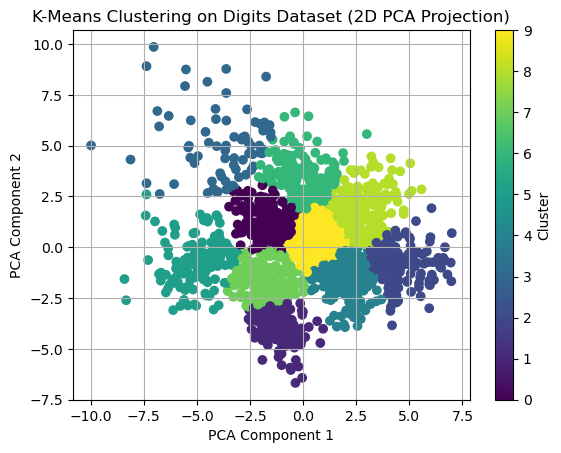

In [9]:
# 28 Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means
from sklearn.datasets import load_digits
X,y=load_digits(return_X_y=True)

X_scaled = StandardScaler().fit_transform(X)
decom= PCA(n_components=2)
X_pca =decom.fit_transform(X_scaled)

kmean=KMeans(n_clusters=10)
kmean.fit_transform(X_pca)
plt.scatter(X_pca[:,0],X_pca[:,1],c=kmean.labels_)
plt.title("K-Means Clustering on Digits Dataset (2D PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

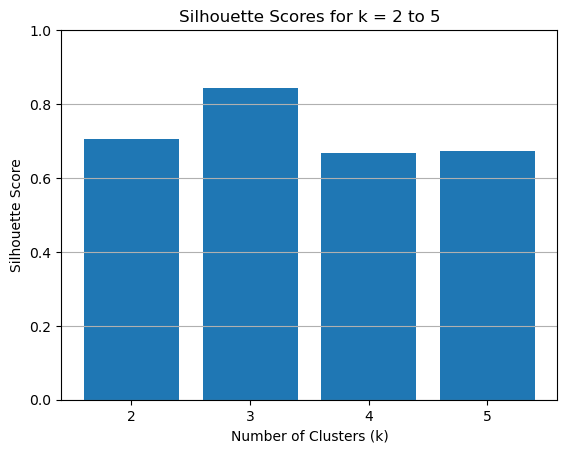

In [10]:
# 29 Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart
X,y= make_blobs(n_samples=1000,n_features=2,random_state=42,)
scores=[]
for i in range(2,6):
    y_labels=KMeans(n_clusters=i).fit_predict(X)
    score=silhouette_score(X,y_labels)
    scores.append(score)
plt.bar([str(i) for i in range(2,6)],scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for k = 2 to 5")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()

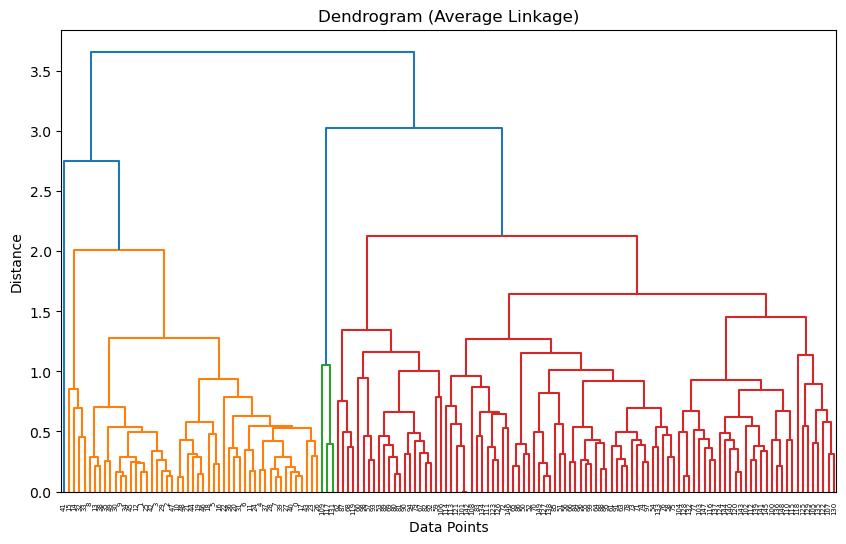

In [11]:
# 30 Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage
X,y = load_iris(return_X_y=True)
scaler =StandardScaler()
X_scale =scaler.fit_transform(X)
model =AgglomerativeClustering(n_clusters=3)
labels=model.fit_predict(X_scale)

import scipy.cluster.hierarchy as sc
plt.figure(figsize=(10, 6))
plt.title("Dendrogram (Average Linkage)")
linkage_matrix = sc.linkage(X_scale, method="average")
sc.dendrogram(linkage_matrix)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


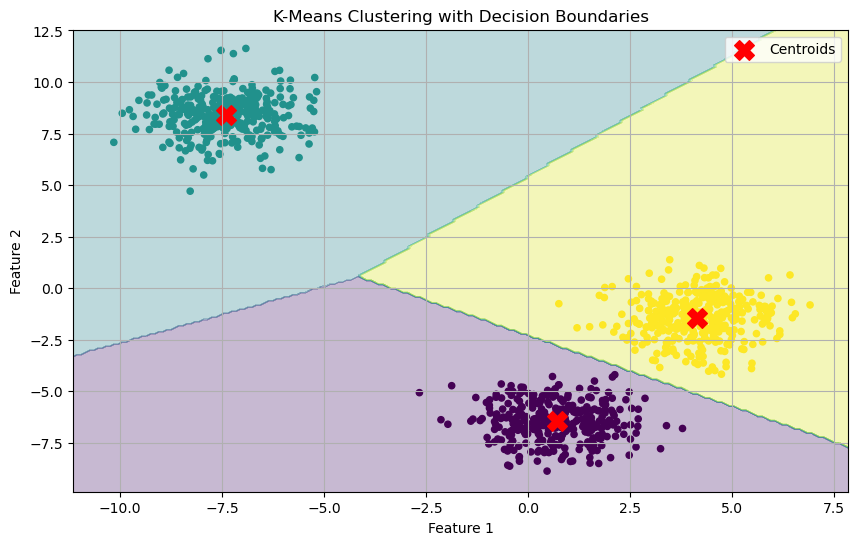

In [12]:
# 31 Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries
X,y =make_blobs(n_features=2,n_samples=1000)
kmeans= KMeans(n_clusters=3)
labels =kmeans.fit_predict(X)
centroids =kmeans.cluster_centers_

# 3. Plot decision boundaries
# Create a mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict cluster for each point in the grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')  # Decision boundaries
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering with Decision Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

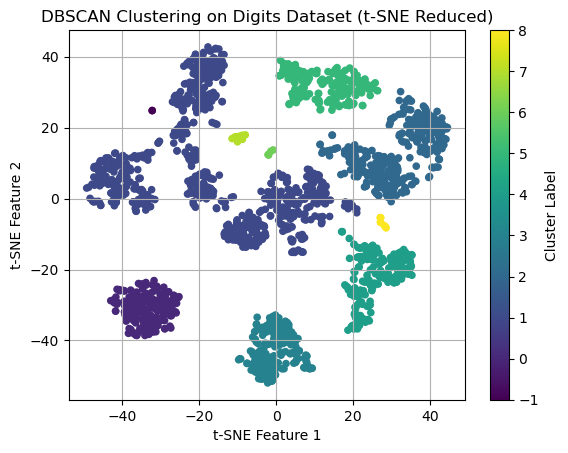

In [13]:
# 32 Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the result
from sklearn.manifold import TSNE
X,y =load_digits(return_X_y=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Reduce to 2D using t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

labels =DBSCAN(eps=5).fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels,  s=20)
plt.title("DBSCAN Clustering on Digits Dataset (t-SNE Reduced)")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.show()

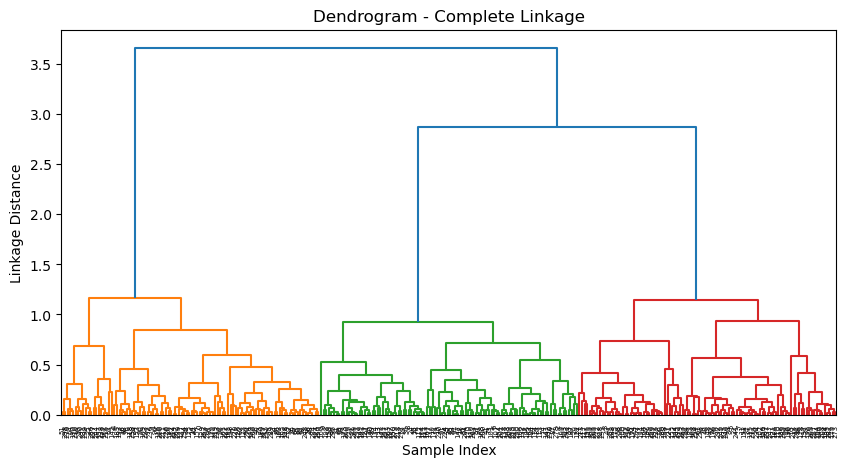

In [14]:
# 33 Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result
X,y =make_blobs(n_features=2,n_samples=300,centers=3 ,random_state=42)
X = StandardScaler().fit_transform(X)
agg=AgglomerativeClustering(n_clusters=4)
labels= agg.fit_predict(X)

plt.figure(figsize=(10, 5))
plt.title("Dendrogram - Complete Linkage")
dendro = sc.dendrogram(sc.linkage(X, method="complete"))
plt.xlabel("Sample Index")
plt.ylabel("Linkage Distance")
plt.show()


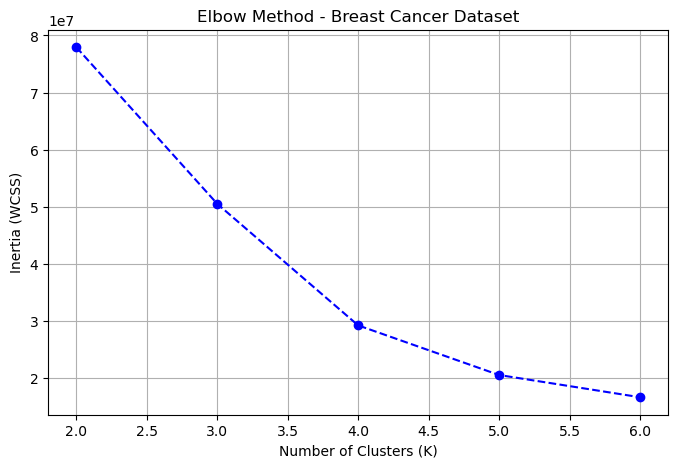

In [15]:
# 34 Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot
X,y =load_breast_cancer(return_X_y=True)
wcss=[]
kvalues=[i for i in range(2,7)]
for i in kvalues:
    kmeans=KMeans(n_clusters=i,)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(kvalues, wcss, marker='o', linestyle='--', color='b')
plt.title("Elbow Method - Breast Cancer Dataset")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.show()

In [16]:
# 35 Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage


In [17]:
# 36 Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)
X,y =load_wine(return_X_y=True)
X=StandardScaler().fit_transform(X)
model =DBSCAN(eps=2)
labels = model.fit_predict(X)
n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
print(" the number of clusters (excluding noise) ",n_cluster)

 the number of clusters (excluding noise)  5


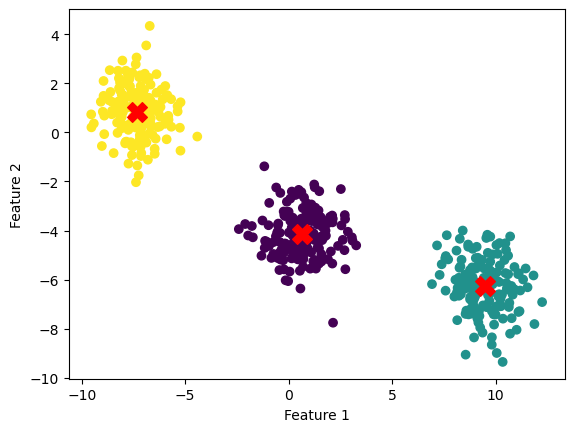

In [18]:
# 37 Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points
X,y =make_blobs(n_features=2,n_samples=500,centers=3)
kmeans= KMeans(n_clusters=3)
labels=kmeans.fit_predict(X)
centeriod= kmeans.cluster_centers_
plt.scatter(X[:,0],X[:,1],c=labels,label="DAta points")
plt.scatter(centeriod[:,0],centeriod[:,1],c="red",marker="X",s=200)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [19]:
# 38 Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise 
X,y =load_iris(return_X_y=True)
X=StandardScaler().fit_transform(X)

dbscan =DBSCAN(eps=1)
labels =dbscan.fit_predict(X)
n_noise = (labels == -1).sum()
print("samples were identified as noise ",n_noise)

samples were identified as noise  3


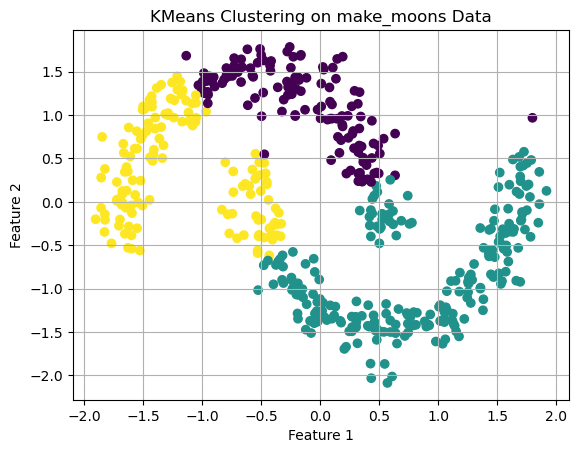

In [20]:
# 39 Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result
X,y =make_moons(n_samples=500,noise=.1)
X =StandardScaler().fit_transform(X)
kmeans=KMeans(n_clusters=3)
labels=kmeans.fit_predict(X)

plt.scatter(X[:,0],X[:,1],c=labels)
plt.title("KMeans Clustering on make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

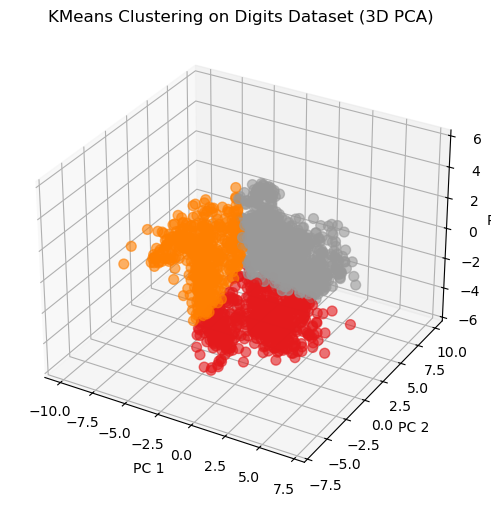

In [21]:
#40 Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
X,y =load_digits(return_X_y=True)
X=StandardScaler().fit_transform(X)
pca =PCA(n_components=3)
X_pca =pca.fit_transform(X)
kmeans=KMeans(n_clusters=3)
labels=kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='Set1', s=50, alpha=0.6)

ax.set_title("KMeans Clustering on Digits Dataset (3D PCA)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.show()


Silhouette Score: 0.6784631220893114


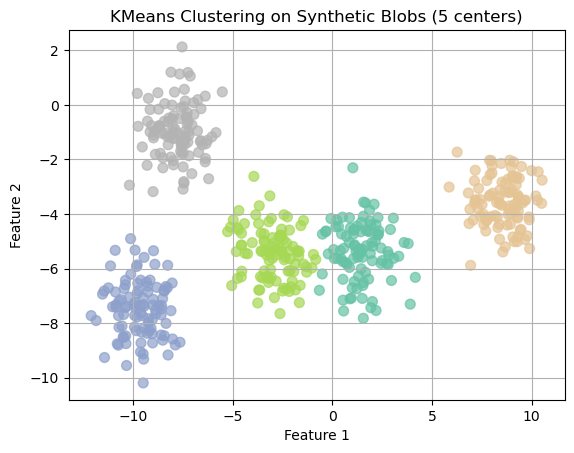

In [22]:
# 41 Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering
X,y =make_blobs(n_features=2,n_samples=500,centers=5)
kmeans=KMeans(n_clusters=5)
labels =kmeans.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set2", s=50, alpha=0.7)
plt.title("KMeans Clustering on Synthetic Blobs (5 centers)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

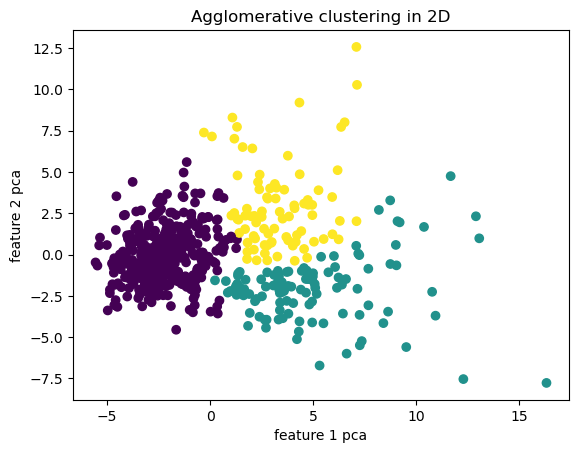

In [23]:
# 42 Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D
X,y =load_breast_cancer(return_X_y=True)
X_scale = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scale)

labels =AgglomerativeClustering(n_clusters=3).fit_predict(X_pca)
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel("feature 1 pca")
plt.ylabel("feature 2 pca")
plt.title("Agglomerative clustering in 2D")
plt.show()

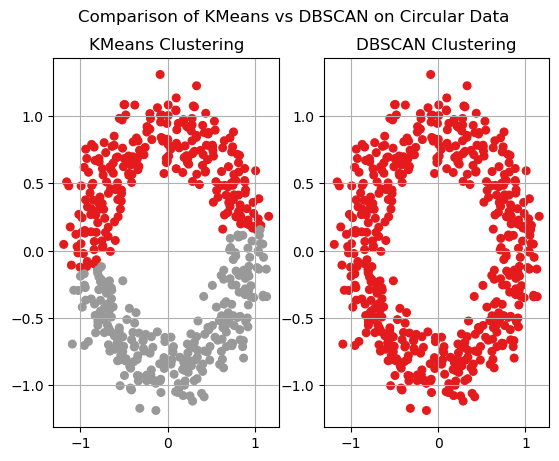

In [24]:
# 43 Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side
X,y =make_circles(n_samples=500,noise=0.1,random_state=42)
labels_kmeans = KMeans(n_clusters=2).fit_predict(X)
labels_dbscan =DBSCAN(eps=2.5).fit_predict(X)

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='Set1', s=30)
plt.title("KMeans Clustering")
plt.grid(True)

# DBSCAN plot
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='Set1', s=30)
plt.title("DBSCAN Clustering")
plt.grid(True)


plt.suptitle("Comparison of KMeans vs DBSCAN on Circular Data")
# plt.tight_layout()
plt.show()


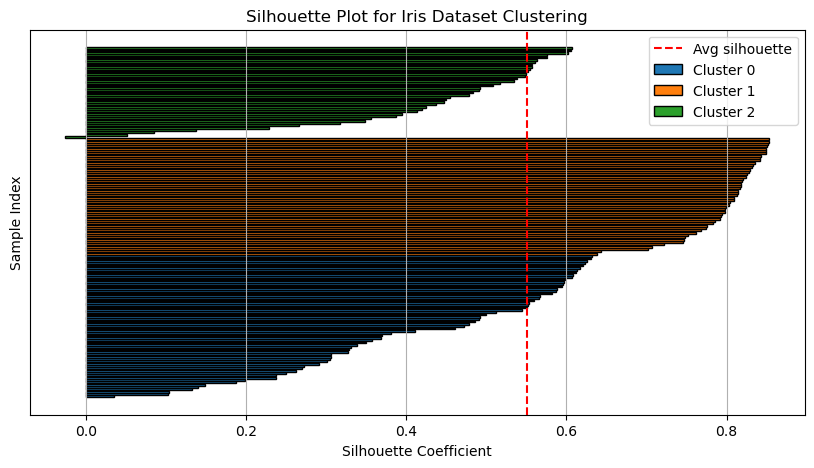

In [26]:
# 44 Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering 
from sklearn.metrics import silhouette_samples
X,y = load_iris(return_X_y=True)
kmeans =KMeans(n_clusters=3,)
labels= kmeans.fit_predict(X)
sample_silhouette_values=silhouette_samples(X,labels)

  
plt.figure(figsize=(10, 5))
y_ticks = []
y_lower = 0

for i in np.unique(labels):
    cluster_silhouette_vals = sample_silhouette_values[labels == i]
    cluster_silhouette_vals.sort()
    y_upper = y_lower + len(cluster_silhouette_vals)
    plt.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='black', label=f'Cluster {i}')
    y_ticks.append((y_lower + y_upper) / 2)
    y_lower = y_upper

plt.axvline(np.mean(sample_silhouette_values), color='red', linestyle='--', label='Avg silhouette')
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index")
plt.title("Silhouette Plot for Iris Dataset Clustering")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show() 


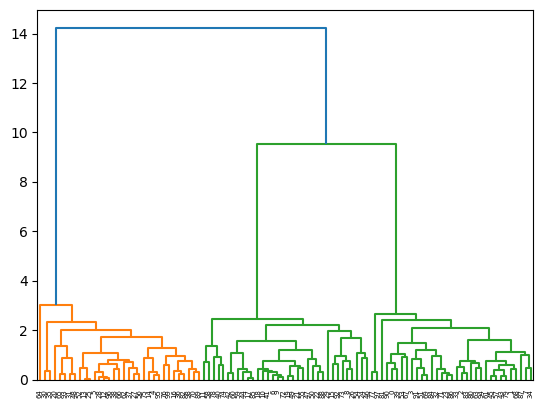

In [27]:
#45 Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.Visualize clusters
X,y =make_blobs(centers=3,n_features=2,n_samples=100,random_state=24)
agg =AgglomerativeClustering(n_clusters=3)
labels =agg.fit_predict(X)

import scipy.cluster.hierarchy as sc
sc.dendrogram(sc.linkage(X,method="average"))
plt.show()

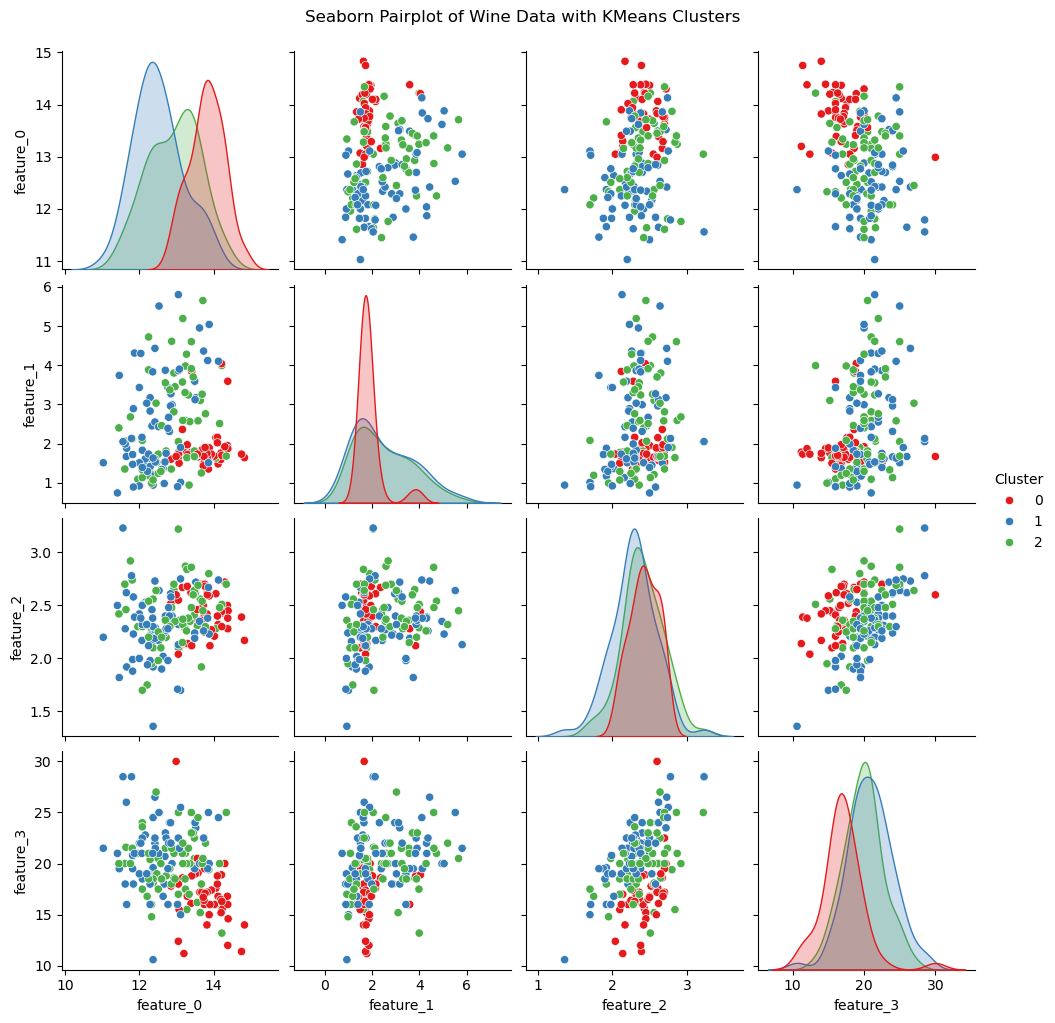

In [28]:
# 46 Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features)
X,y =load_wine(return_X_y=True)
labels =KMeans(n_clusters=3).fit_predict(X)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df = df.iloc[:, :4]  # Only first 4 features
df['Cluster']=labels
import seaborn as sns
sns.pairplot(df, hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle("Seaborn Pairplot of Wine Data with KMeans Clusters", y=1.02)
plt.show()

In [29]:
# 47  Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count
X,y =make_blobs(n_features=2,n_samples=1000,cluster_std=2)
dbscan = DBSCAN(eps=1)
labels =dbscan.fit_predict(X)

n_clusters= len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print("Number of clusters (excluding noise):", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters (excluding noise): 1
Number of noise points: 24


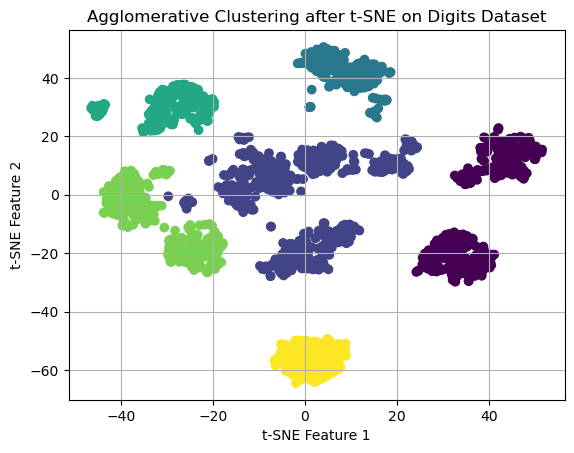

In [30]:
#48 Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
X,y =load_digits(return_X_y=True)
X_tsne = TSNE(n_components=2).fit_transform(X)

labels =AgglomerativeClustering(n_clusters=6).fit_predict(X_tsne)
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=labels)
plt.title("Agglomerative Clustering after t-SNE on Digits Dataset")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.grid(True)
plt.show()